_Source_:
<p>
Slip-Link model – a single-chain picture of entangled polymer dynamics <br>
adopted from Likhtman, Macromolecules 38, 6128 (2005)
</p>

sequential algorithm: exhaust segment moves first and then exhaust slip-links moves

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from tqdm import tqdm

In [2]:
def generate_anchors_positions(positions_segments, attach):
    positions_anchors = np.zeros((len(attach), 3))

    for idx, a in enumerate(attach):
        positions_anchors[idx] = np.random.normal(positions_segments[a], np.sqrt(Re**2/(3*(N-1)*beta)))
        
        # print(idx, a, positions_segments[a])
    return positions_anchors

def bonded_energy(positions_segments):
    u = 0
    for segment in range(1, len(positions_segments)):
        u += np.linalg.norm(positions_segments[segment] - positions_segments[segment-1])**2

    # u *= 3*(N-1)/(2*Re**2)
    return u

def slipSpring_energy(positions_segments, positions_anchors, anchor):
    w = 0
    
    for idx, a in enumerate(anchor):
        if a == -1:
            continue
        else:
            w += np.linalg.norm(positions_segments[idx] - positions_anchors[a])**2
        # print(a, positions_segments[idx], positions_anchors[a])
    # w *= 3*(N-1)/(2*Re**2)
    return w

def hamiltonian(positions_segments, positions_anchors, anchor):
    h = bonded_energy(positions_segments) + beta*slipSpring_energy(positions_segments, positions_anchors, anchor)
    h *= 3*(N-1)/(2*Re**2)
    return h

def mc_segments(positions_segments, positions_anchors, H_current):
    H_accumulated = 0
    for _ in range(N):
        segment = np.random.randint(0, N) # segment chosen at random
        
        old_pos = positions_segments[segment].copy()
        
        positions_segments[segment] += np.random.uniform(-a, a, 3)
        H_proposal = hamiltonian(positions_segments, positions_anchors, anchor)
        H_delta = H_proposal - H_current

        if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB*T)):
            H_current = H_proposal
            H_accumulated += H_delta
        else:
            positions_segments[segment] = old_pos

    return positions_segments, positions_anchors, H_current, H_accumulated

def mc_sliplinks(positions_segments, positions_anchors, anchor, attach, H_current):
    H_accumulated = 0
    
    for _ in range(Z):
        j = np.random.randint(0, Z) # slip-link chosen at random
        
        current_attachment = attach[j].copy() # choosing the random attachment point
        proposal_attachment = current_attachment + np.random.choice([-1, 1])

        # Check if the proposal is withing bounds
        if proposal_attachment == -1 or proposal_attachment == N:
            if j%2 == 0:
                j_partner = j+1
            else:
                j_partner = j-1

            # if not, then
            # remove the slip-link duo
            for sliplink in [j, j_partner]:
                segment = attach[sliplink]

                if segment != -1 and anchor[segment] == sliplink:
                    attach[sliplink] = -1
                    anchor[segment] = -1
            

            # tube renewal
            available_ends = [i for i in [0, N-1] if anchor[i] == -1]
            if len(available_ends) < 1:
                continue
                
            free_chain_end = np.random.choice(available_ends)
            positions_anchors[j] = np.random.normal(positions_segments[free_chain_end], np.sqrt(Re**2/(3*(N-1)*beta)))
            attach[j] = free_chain_end
            anchor[free_chain_end] = j

            # constraint release
            free_beads = np.where(anchor==-1)[0]
            if len(free_beads) < 1:
                continue 
                
            partner_bead = np.random.choice(free_beads)
            positions_anchors[j_partner] = np.random.normal(positions_segments[partner_bead], np.sqrt(Re**2/(3*(N-1)*beta)))
            attach[j_partner] = partner_bead
            anchor[partner_bead] = j_partner

            continue

        anchor_trial = anchor.copy()
        attach_trial = attach.copy()
        if anchor[proposal_attachment] != -1:
            continue
            
        anchor_trial[current_attachment] = -1
        anchor_trial[proposal_attachment] = j
        attach_trial[j] = proposal_attachment

        H_proposal = hamiltonian(positions_segments, positions_anchors, anchor_trial)
        H_delta = H_proposal - H_current

        if H_delta <= 0 or np.random.rand() < np.exp(-H_delta / (kB*T)):
            H_current = H_proposal
            anchor = anchor_trial
            attach = attach_trial
            # anchor[current_attachment] = -1 # remove attachment at the chosen sliplink idx
            # anchor[proposal_attachment] = j # add attachment at the proposed sliplink idx
            # attach[j] = proposal_attachment
            H_accumulated += H_delta

        else:
            pass
            # anchor[current_attachment] = j
            # anchor[proposal_attachment] = -1
            # attach[j] = current_attachment

    assert np.count_nonzero(attach != -1) == Z
    assert np.count_nonzero(anchor != -1) == Z

    return positions_segments, positions_anchors, anchor, attach, H_current, H_accumulated

In [3]:
def plotter(positions_segments, anchor, positions_anchors, step):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Chain backbone
    ax.plot(positions_segments[:, 0], positions_segments[:, 1], positions_segments[:, 2], "-", color="k", alpha=0.5)

    # Beads
    for segment in range(len(positions_segments)):
        if anchor[segment] == -1:
            ax.scatter(*positions_segments[segment], color="k", facecolors="none", alpha=0.8)
        else:
            ax.scatter(*positions_segments[segment], color="k", alpha=0.8)

    # Chain ends
    ax.scatter(*positions_segments[0], color="b", marker="s", s=60, facecolors="none", label="bead N=1")
    ax.scatter(*positions_segments[-1], color="g", marker="s", s=60, facecolors="none", label=f"bead N={len(positions_segments)}")

    # Anchor connections
    for idx, a in enumerate(anchor):
        if a != -1:
            ax.plot(
                [positions_anchors[a, 0], positions_segments[idx, 0]],
                [positions_anchors[a, 1], positions_segments[idx, 1]],
                [positions_anchors[a, 2], positions_segments[idx, 2]],
                color='red', linestyle='-', linewidth=1, alpha=0.4
            )
            ax.scatter(
                *positions_anchors[a],
                color='red', marker="s", alpha=0.4, s=10
            )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right")
    ax.grid(False)

    ax.set_title(f"step {step}")
    fig.tight_layout()

    output_filepath = f"data/imgs/mcmc/evolution/"
    output_filename = f"step_{step:06d}.png"
    
    if not os.path.exists(output_filepath):
        os.makedirs(output_filepath)
    file = os.path.join(output_filepath, output_filename)
    
    plt.savefig(file, dpi=300)
    plt.close()

In [4]:
def initialize(N, Z):
    # Initialize polymer
    positions_segments = np.zeros((N, dims))
    
    # whereby, assumed that the first segment is initialized at (0, 0, 0)
    for segment in range(1, N):
        # print(segment)
        positions_segments[segment] = positions_segments[segment-1] + np.random.normal(0, 1, dims)
    
    # Beads with slip-springs
    # Get the index of the beads with the slip spring
    attach = np.random.choice(N, Z, replace=False)
    
    # "idx-ordered" list of slip springs (similar to a hash table)
    anchor = -1*np.ones(N, dtype=np.int64)
    for idx, link in enumerate(attach):
        anchor[link] = idx
    
    positions_anchors = generate_anchors_positions(positions_segments, attach)
    
    # Visualize initial config.
    # plotter(positions_segments, anchor, positions_anchors, step=0)

    return positions_segments, positions_anchors, anchor, attach

In [10]:
# System Parameters
dims = 3 # Space dimensions

kB = 1
T = 1

N = 16 # Number of segments
Re = 1 # Polymer end-to-end distance
beta = 0.5 # Anchor-segment stiffness (?)
a = 2*Re/np.sqrt(N-1) # bead "exploratory" linear dimension -> any proposal confined within such a cube

N_steps = 15000 # MC steps
N_realizations = 50 # ensemble
# Z = N//4 # Number of slip links


In [11]:
###################
# Limit Z = 0
###################
Z = 0 # Number of slip links


R_all = []

E_all = []
U_all = [] # stores [in, fi] pairs
W_all = [] # stores [in, fi] pairs
H_accumulated_all = [] # stores the accumulated energy per move acceptance for every realization

g3_all = []
g1_all = []

for realization in (range(N_realizations)):

    # Initialize the system
    positions_segments, positions_anchors, anchor, attach = initialize(N, Z)
    
    # print("\nInitial")
    # print(f"Bonded energy {bonded_energy(positions_segments):.2f}, Slip-Spring energy {slipSpring_energy(positions_segments, positions_anchors, anchor):.2f}")
    # print(f"Total energy {hamiltonian(positions_segments, positions_anchors, anchor):.2f}")

    # Initial position of the Centre of Mass
    X0 = np.mean(positions_segments, axis=0)

    # Initial positions of the segments
    r0 = positions_segments.copy()
    
    R = [] # end-to-end chain length per time-step
    E = [] # energy of the chain per time-step
    g3 = [] # MSD of COM per time-step
    g1 = [] # MSD of segments per time_step 

    u_in = bonded_energy(positions_segments)
    w_in = slipSpring_energy(positions_segments, positions_anchors, anchor)

    H_accumulated = 0
    
    for step in tqdm(range(N_steps), desc=f"realization {realization}"):
        # if step%100 == 0:
        #     plotter(positions_segments, anchor, positions_anchors, step)
        
        H_current = hamiltonian(positions_segments, positions_anchors, anchor)
        
        # MC on segment
        positions_segments, positions_anchors, H_current, _ = mc_segments(positions_segments, positions_anchors, H_current)
        H_accumulated += _
        
        # MC on slip-links
        positions_segments, positions_anchors, anchor, attach, H_current, _ = mc_sliplinks(positions_segments, positions_anchors, anchor, attach, H_current)
        H_accumulated += _

        
        # print(attach)
        # print(current_attachment, proposal_attachment)
        # print(f"step {step}")
        
        X = np.mean(positions_segments, axis=0) # position of COM at the current step
        g3.append(np.linalg.norm(X-X0)**2)

        g1_temp = np.linalg.norm((X-X0) + (positions_segments-r0), axis=1)**2
        # g1_temp = np.linalg.norm((positions_segments-r0), axis=1)
        
        g1.append(g1_temp)
        # g1_temp = np.linalg.norm(X-X0 + positions_segments-r0)**2
        # g1.append(g1_temp)
        # g1.append(np.mean((np.linalg.norm(positions_segments-r0)**2))) # average of msd of all the segments
        
        R.append(np.linalg.norm(positions_segments[-1]-positions_segments[0]))
        E.append(hamiltonian(positions_segments, positions_anchors, anchor))
    
    u_fi = bonded_energy(positions_segments)
    w_fi = slipSpring_energy(positions_segments, positions_anchors, anchor)
    
    R_all.append(R)
    
    E_all.append(E)
    U_all.append([u_in, u_fi])
    W_all.append([w_in, w_fi])
    H_accumulated_all.append(H_accumulated)
    
    g1_all.append(g1)
    g3_all.append(g3)
    
    
    # print("Final")
    # print(f"Bonded energy {bonded_energy(positions_segments):.2f}, Slip-Spring energy {slipSpring_energy(positions_segments, positions_anchors, anchor):.2f}")
    # print(f"Total energy {hamiltonian(positions_segments, positions_anchors, anchor):.2f}")
    

realization 49: 100%|███████████████████| 15000/15000 [00:08<00:00, 1680.27it/s]


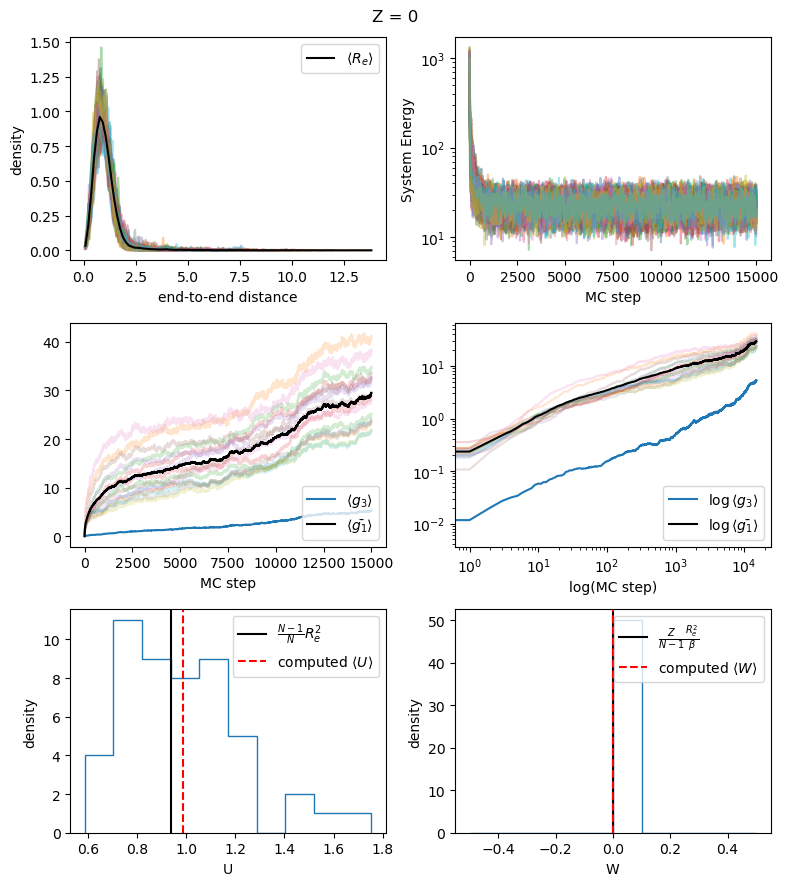

In [12]:
fig, ax = plt.subplots(3, 2, figsize = (8, 9))

for R in R_all:
    counts, bins = np.histogram(R, bins=100, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax[0, 0].plot(bin_centers, counts, alpha=0.4)
counts, bins = np.histogram(np.asarray(R_all).flatten(), bins=100, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax[0, 0].plot(bin_centers, counts, color="k", label = r"$\langle R_e \rangle$")
ax[0, 0].set_xlabel("end-to-end distance")
ax[0, 0].set_ylabel("density")
ax[0, 0].legend(loc="upper right")

for E in E_all:
    ax[0, 1].plot(range(N_steps), E, alpha=0.4)
    ax[0, 1].set_xlabel("MC step")
    ax[0, 1].set_ylabel("System Energy")
ax[0, 1].set_yscale("log")



ax[1, 0].plot(range(N_steps), np.mean(g3_all, axis=0), label=r"$\langle g_3 \rangle$")
for bead in range(N):
    ax[1, 0].plot(range(N_steps), np.mean(g1_all, axis=0)[:, bead], alpha=0.2)
ax[1, 0].plot(range(N_steps), np.mean(np.mean(g1_all, axis=0), axis=1), color="k", label=r"$\langle \bar{g_1} \rangle$")
ax[1, 0].set_xlabel("MC step")
ax[1, 0].legend(loc="lower right")


ax[1, 1].plot(range(N_steps), np.mean(g3_all, axis=0), label=r"$\log\langle g_3 \rangle$")
for bead in range(N):
    ax[1, 1].plot(range(N_steps), np.mean(g1_all, axis=0)[:, bead], alpha=0.2)
ax[1, 1].plot(range(N_steps), np.mean(np.mean(g1_all, axis=0), axis=1), color="k", label=r"$\log \langle \bar{g_1} \rangle$")
ax[1, 1].set_xlabel("log(MC step)")
ax[1, 1].legend(loc="lower right")
ax[1, 1].set_xscale("log")
ax[1, 1].set_yscale("log")


U_fi = []
for U in U_all:
    U_fi.append(U[1])
ax[2, 0].hist(U_fi, histtype="step", bins=10)
ax[2, 0].axvline(Re**2*(N-1)/N, color="k", label=r"$\frac{N-1}{N}R_e^2$")
ax[2, 0].axvline(np.mean(U_fi), color="r", linestyle = "--", label=r"computed $\langle U \rangle$")
ax[2, 0].set_xlabel("U")
ax[2, 0].set_ylabel("density")
ax[2, 0].legend(loc="upper right")

W_fi = []
for W in W_all:
    W_fi.append(W[1])
ax[2, 1].hist(W_fi, histtype="step", bins=10)
ax[2, 1].axvline(Re**2*Z/((N-1)*beta), color="k", label=r"$\frac{Z}{N-1}\frac{R_e^2}{\beta}$")
ax[2, 1].axvline(np.mean(W_fi), color="r", linestyle = "--", label=r"computed $\langle W \rangle$")
ax[2, 1].set_xlabel("W")
ax[2, 1].set_ylabel("density")
ax[2, 1].legend(loc="upper right")

fig.suptitle("Z = 0")
fig.tight_layout()

In [13]:
###################
# Limit Z = N//4
###################
Z = N//4 # Number of slip links


R_all = []

E_all = []
U_all = [] # stores [in, fi] pairs
W_all = [] # stores [in, fi] pairs
H_accumulated_all = [] # stores the accumulated energy per move acceptance for every realization

g3_all = []
g1_all = []

for realization in (range(N_realizations)):

    # Initialize the system
    positions_segments, positions_anchors, anchor, attach = initialize(N, Z)
    
    # print("\nInitial")
    # print(f"Bonded energy {bonded_energy(positions_segments):.2f}, Slip-Spring energy {slipSpring_energy(positions_segments, positions_anchors, anchor):.2f}")
    # print(f"Total energy {hamiltonian(positions_segments, positions_anchors, anchor):.2f}")

    # Initial position of the Centre of Mass
    X0 = np.mean(positions_segments, axis=0)

    # Initial positions of the segments
    r0 = positions_segments.copy()
    
    R = [] # end-to-end chain length per time-step
    E = [] # energy of the chain per time-step
    g3 = [] # MSD of COM per time-step
    g1 = [] # MSD of segments per time_step 

    u_in = bonded_energy(positions_segments)
    w_in = slipSpring_energy(positions_segments, positions_anchors, anchor)

    H_accumulated = 0
    
    for step in tqdm(range(N_steps), desc=f"realization {realization}"):
        # if step%100 == 0:
        #     plotter(positions_segments, anchor, positions_anchors, step)
        
        H_current = hamiltonian(positions_segments, positions_anchors, anchor)
        
        # MC on segment
        positions_segments, positions_anchors, H_current, _ = mc_segments(positions_segments, positions_anchors, H_current)
        H_accumulated += _
        
        # MC on slip-links
        positions_segments, positions_anchors, anchor, attach, H_current, _ = mc_sliplinks(positions_segments, positions_anchors, anchor, attach, H_current)
        H_accumulated += _

        
        # print(attach)
        # print(current_attachment, proposal_attachment)
        # print(f"step {step}")
        
        X = np.mean(positions_segments, axis=0) # position of COM at the current step
        g3.append(np.linalg.norm(X-X0)**2)

        g1_temp = np.linalg.norm((X-X0) + (positions_segments-r0), axis=1)**2
        # g1_temp = np.linalg.norm((positions_segments-r0), axis=1)
        
        g1.append(g1_temp)
        # g1_temp = np.linalg.norm(X-X0 + positions_segments-r0)**2
        # g1.append(g1_temp)
        # g1.append(np.mean((np.linalg.norm(positions_segments-r0)**2))) # average of msd of all the segments
        
        R.append(np.linalg.norm(positions_segments[-1]-positions_segments[0]))
        E.append(hamiltonian(positions_segments, positions_anchors, anchor))
    
    u_fi = bonded_energy(positions_segments)
    w_fi = slipSpring_energy(positions_segments, positions_anchors, anchor)
    
    R_all.append(R)
    
    E_all.append(E)
    U_all.append([u_in, u_fi])
    W_all.append([w_in, w_fi])
    H_accumulated_all.append(H_accumulated)
    
    g1_all.append(g1)
    g3_all.append(g3)
    
    
    # print("Final")
    # print(f"Bonded energy {bonded_energy(positions_segments):.2f}, Slip-Spring energy {slipSpring_energy(positions_segments, positions_anchors, anchor):.2f}")
    # print(f"Total energy {hamiltonian(positions_segments, positions_anchors, anchor):.2f}")
    

realization 49: 100%|███████████████████| 15000/15000 [00:13<00:00, 1138.61it/s]


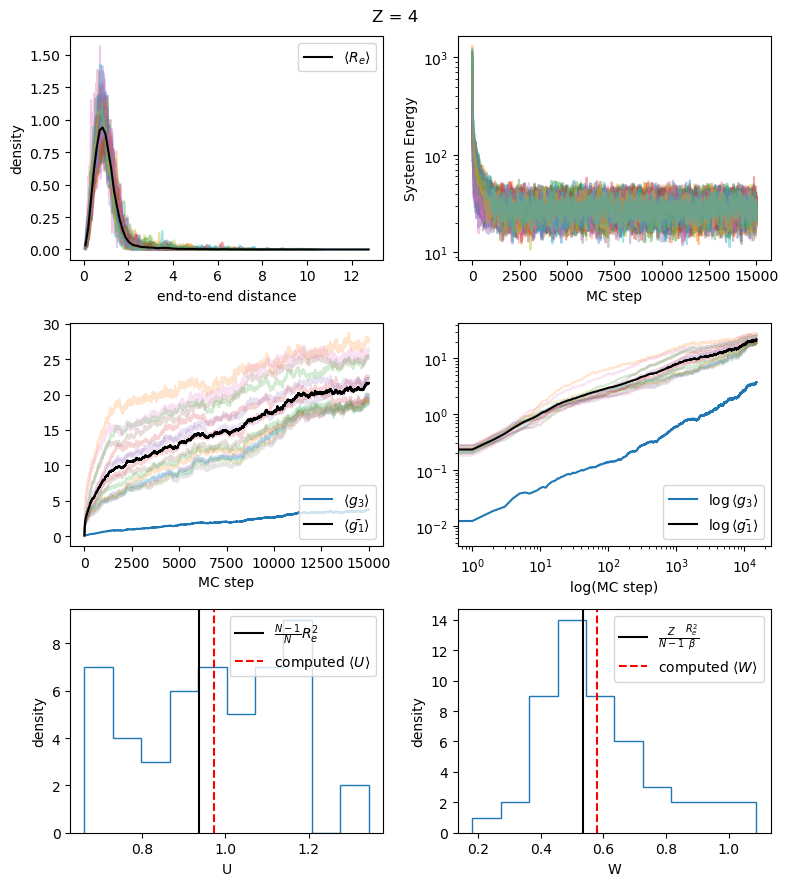

In [16]:
fig, ax = plt.subplots(3, 2, figsize = (8, 9))

for R in R_all:
    counts, bins = np.histogram(R, bins=100, density=True)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ax[0, 0].plot(bin_centers, counts, alpha=0.4)
counts, bins = np.histogram(np.asarray(R_all).flatten(), bins=100, density=True)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax[0, 0].plot(bin_centers, counts, color="k", label = r"$\langle R_e \rangle$")
ax[0, 0].set_xlabel("end-to-end distance")
ax[0, 0].set_ylabel("density")
ax[0, 0].legend(loc="upper right")

for E in E_all:
    ax[0, 1].plot(range(N_steps), E, alpha=0.4)
    ax[0, 1].set_xlabel("MC step")
    ax[0, 1].set_ylabel("System Energy")
ax[0, 1].set_yscale("log")



ax[1, 0].plot(range(N_steps), np.mean(g3_all, axis=0), label=r"$\langle g_3 \rangle$")
for bead in range(N):
    ax[1, 0].plot(range(N_steps), np.mean(g1_all, axis=0)[:, bead], alpha=0.2)
ax[1, 0].plot(range(N_steps), np.mean(np.mean(g1_all, axis=0), axis=1), color="k", label=r"$\langle \bar{g_1} \rangle$")
ax[1, 0].set_xlabel("MC step")
ax[1, 0].legend(loc="lower right")


ax[1, 1].plot(range(N_steps), np.mean(g3_all, axis=0), label=r"$\log\langle g_3 \rangle$")
for bead in range(N):
    ax[1, 1].plot(range(N_steps), np.mean(g1_all, axis=0)[:, bead], alpha=0.2)
ax[1, 1].plot(range(N_steps), np.mean(np.mean(g1_all, axis=0), axis=1), color="k", label=r"$\log \langle \bar{g_1} \rangle$")
ax[1, 1].set_xlabel("log(MC step)")
ax[1, 1].legend(loc="lower right")
ax[1, 1].set_xscale("log")
ax[1, 1].set_yscale("log")


U_fi = []
for U in U_all:
    U_fi.append(U[1])
ax[2, 0].hist(U_fi, histtype="step", bins=10)
ax[2, 0].axvline(Re**2*(N-1)/N, color="k", label=r"$\frac{N-1}{N}R_e^2$")
ax[2, 0].axvline(np.mean(U_fi), color="r", linestyle = "--", label=r"computed $\langle U \rangle$")
ax[2, 0].set_xlabel("U")
ax[2, 0].set_ylabel("density")
ax[2, 0].legend(loc="upper right")

W_fi = []
for W in W_all:
    W_fi.append(W[1])
ax[2, 1].hist(W_fi, histtype="step", bins=10)
ax[2, 1].axvline(Re**2*Z/((N-1)*beta), color="k", label=r"$\frac{Z}{N-1}\frac{R_e^2}{\beta}$")
ax[2, 1].axvline(np.mean(W_fi), color="r", linestyle = "--", label=r"computed $\langle W \rangle$")
ax[2, 1].set_xlabel("W")
ax[2, 1].set_ylabel("density")
ax[2, 1].legend(loc="upper right")

fig.suptitle(f"Z = {Z}")
fig.tight_layout()